In [2]:
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, inv
import numpy as np

In [3]:
def bwgd_discard(y, A, eta, niter, threshold):
    d, n = A.shape  
    x = np.zeros((niter, d))  
    x[0] = np.random.randn(d)  

    # Descent
    for iter in range(1, niter):
        # Discard samples
        indices = np.abs(A.T @ x[iter - 1]) >= threshold        
        A_filtered = A.T[indices].T.copy()
        y_filtered = y[indices].copy()

        # Covariance matrix transform
        C = A_filtered @ A_filtered.T / n
        C_sqrt = sqrtm(C)
        C_inv = np.real(inv(C_sqrt))
        A_tilde = C_inv @ A_filtered 
        x_tilde = C_sqrt @ x[iter - 1]

        # Descent
        sum_gradient = A_tilde @ (np.sqrt(y_filtered) * (A_tilde.T @ x_tilde) / np.abs(A_tilde.T @ x_tilde))
        x_tilde = (1 - eta) * x_tilde + (eta / n) * sum_gradient

        x[iter] = C_inv @ x_tilde
        
    return x

In [16]:
# Take minimum error for positive and negative x
def min_error(x_hat, x_star):
    errors = []
    for x in x_hat:
            error_positive = np.linalg.norm(x_star - x)
            error_negative = np.linalg.norm(-1*x_star - x)
            errors.append(min(error_positive, error_negative))
    return errors

In [44]:
# Returns the convergence count for errors for a set of test parameters
def convergence_counts(errors, parameter):
    zero_error = {}
    for i in range(len(errors)):
        zero_error[parameter[i]] = 0
        for error in errors[i]:
            zero_error[parameter[i]] += error[-1] < 1e-11
    return zero_error

Varying thresholds

C:\Users\gabreu\AppData\Local\Temp\ipykernel_9900\1127232305.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  x[iter] = C_inv @ x_tilde


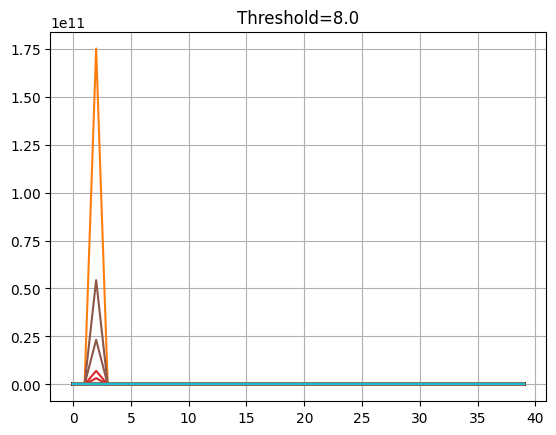

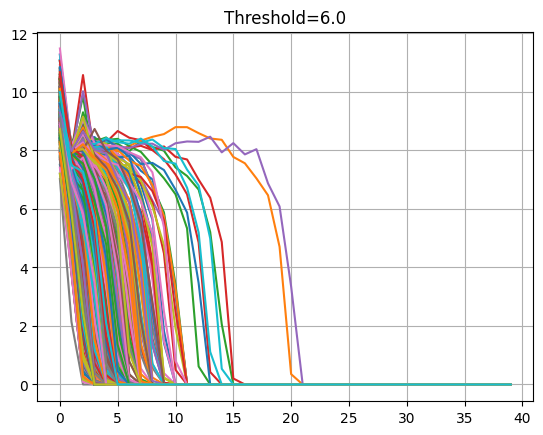

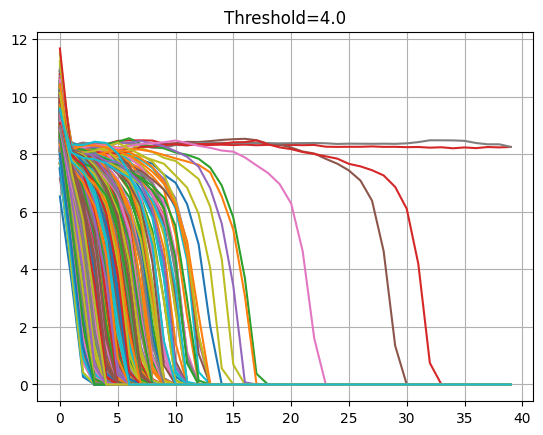

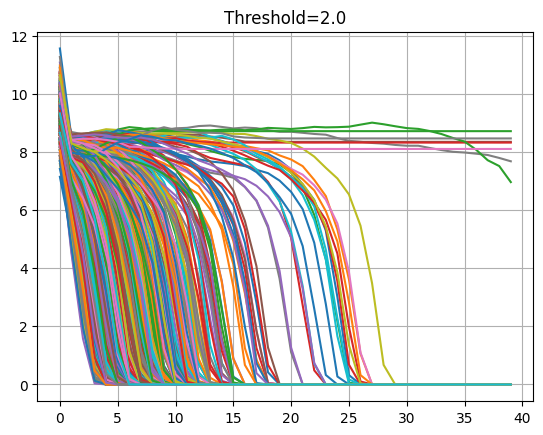

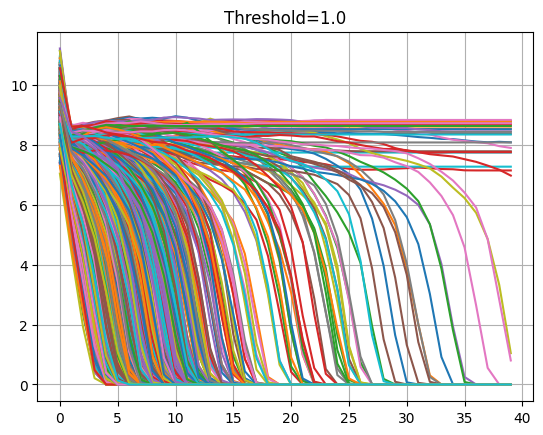

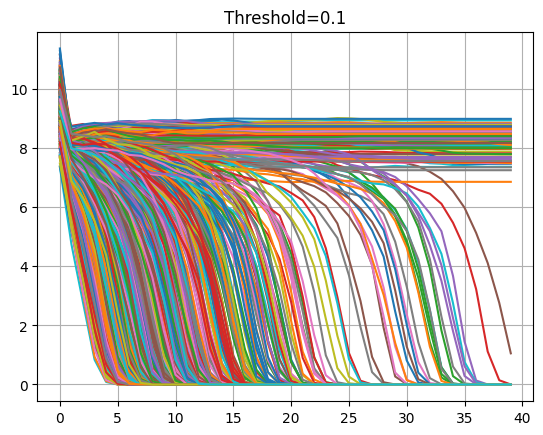

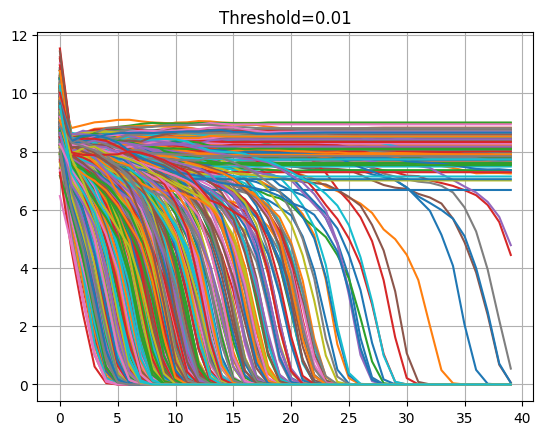

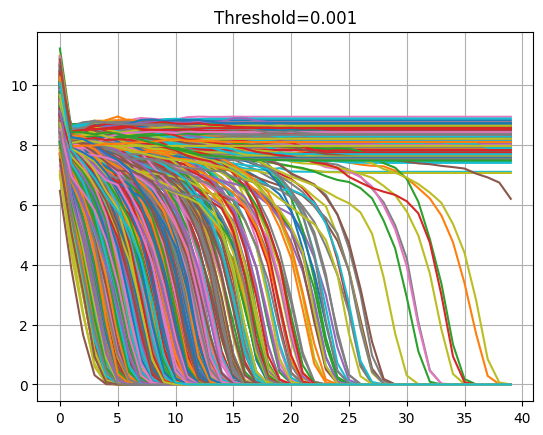

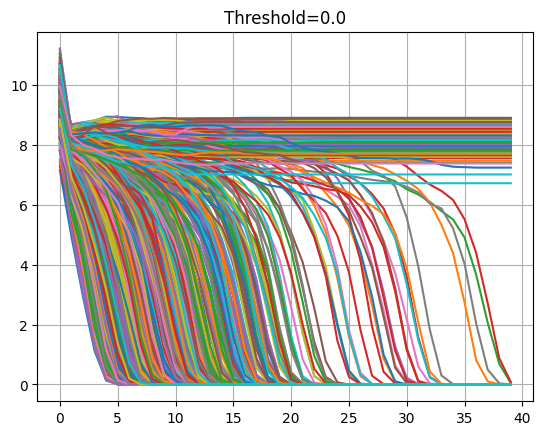

In [27]:
n = 1000
d = 50
errors = []
thresholds =  np.array([8, 6, 4, 2, 1e+00, 1e-01, 1e-02, 1e-03, 0])

for threshold in thresholds:
    threshold_error = []
    for j in range(1, 1001):  
        # Generate vectors
        x = np.ones(d)
        A = np.random.randn(d, n)
        y = np.square(A.T @ x)
        
        # Run the algorithm
        x_hat = bwgd_discard(y, A, 1, 40, threshold)

        error = min_error(x_hat, x)
        threshold_error.append(error)
        
        # Plot results
        plt.plot(error)

    errors.append(threshold_error)

    plt.title(f'Threshold={threshold}')
    plt.grid(True)
    plt.show()

In [64]:
convergence_counts(errors, thresholds)

{8.0: 0, 6.0: 0, 4.0: 60, 2.0: 99, 1.0: 100, 0.1: 100}

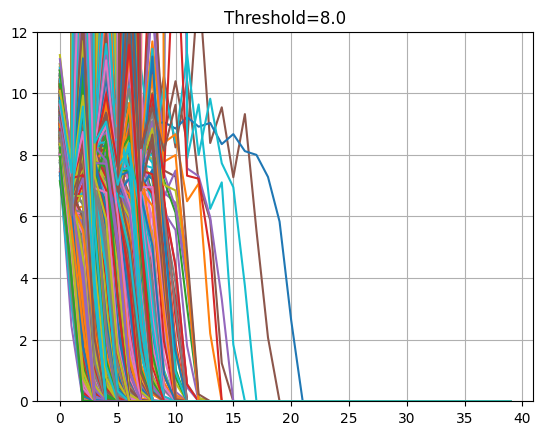

In [46]:
for i in errors[0]:
    plt.plot(i)
plt.title(f'Threshold={thresholds[0]}')
plt.ylim(0,12)
plt.grid(True)
plt.show()

Varying Samples

C:\Users\gabreu\AppData\Local\Temp\ipykernel_9900\1127232305.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  x[iter] = C_inv @ x_tilde


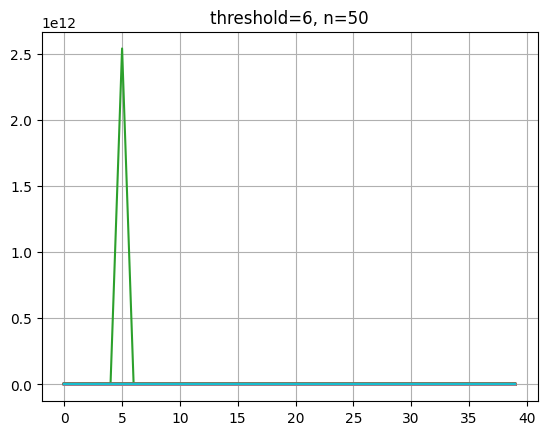

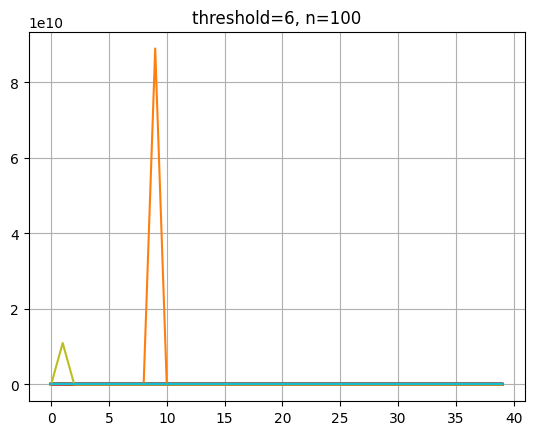

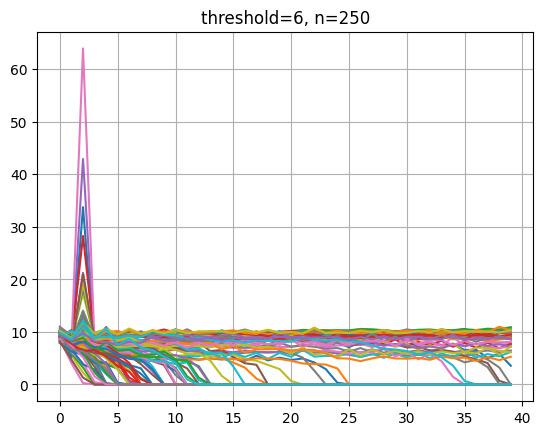

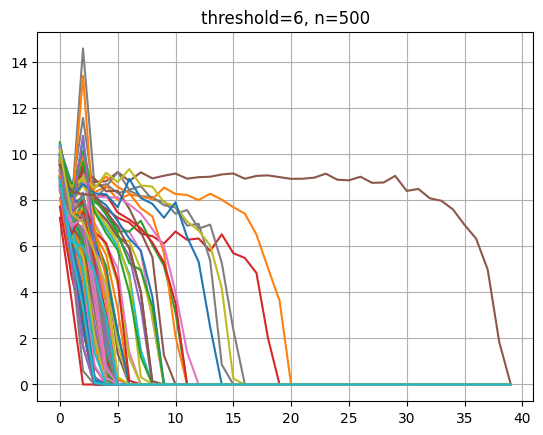

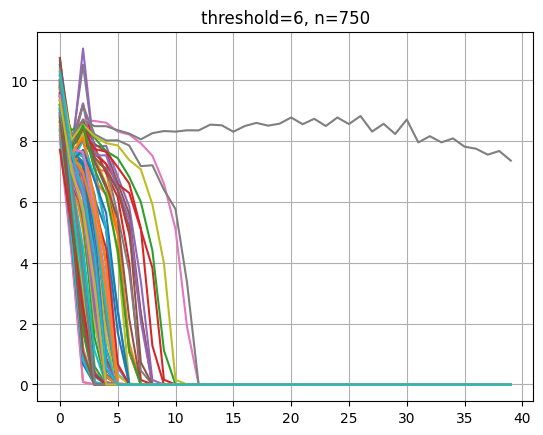

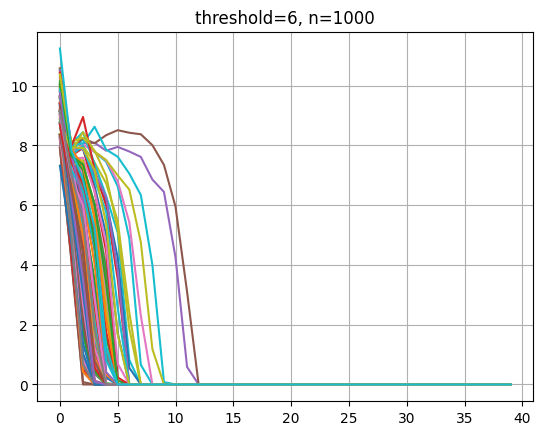

In [79]:
d = 50
n_vals = [50, 100, 250, 500, 750, 1000]
errors = []

for n in n_vals:
    n_error = []
    for j in range(1, 101):  
        # Generate vectors
        x = np.ones(d)
        A = np.random.randn(d, n)
        y = np.square(A.T @ x)
        
        # Run the algorithm
        x_hat = bwgd_discard(y, A, 1, 40, 6)

        error = min_error(x_hat, x)
        n_error.append(error)
        
        # Plot results
        plt.plot(error)

    errors.append(n_error)

    plt.title(f'n={n}')
    plt.grid(True)
    plt.show()

In [80]:
convergence_counts(errors, n_vals)

{50: 0, 100: 0, 250: 66, 500: 100, 750: 99, 1000: 100}

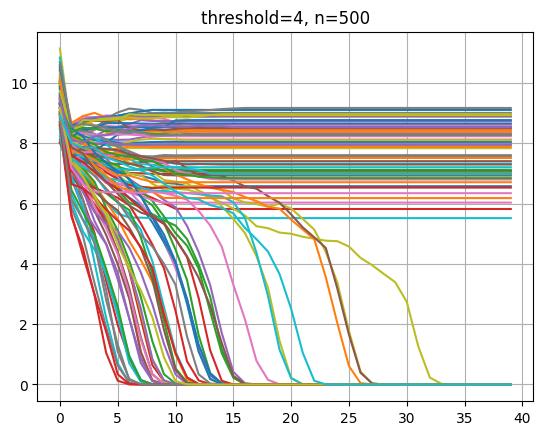

47

In [98]:
z = 0
for j in range(1, 101): 
    n= 500
    # Generate vectors
    x = np.ones(d)
    A = np.random.randn(d, n)
    y = np.square(A.T @ x)
        
    # Run the algorithm
    x_hat = bwgd_discard(y, A, 1, 40, 0)

    error = min_error(x_hat, x)        
     # Plot results
    plt.plot(error)
    z += error[-1] < 1e-11


plt.title(f'threshold=4, n={n}')
plt.grid(True)
plt.show()
z